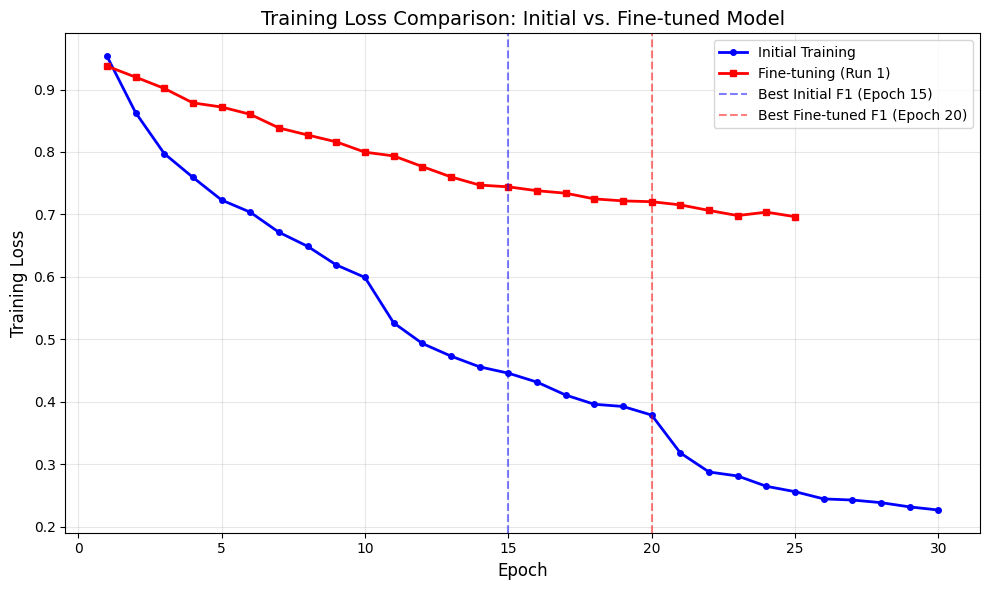

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data from your training history
epochs = list(range(1, 31))
initial_loss = [0.9536, 0.8632, 0.7975, 0.7594, 0.7231, 0.7036, 0.6715, 0.6490, 0.6192, 0.5992,
                0.5265, 0.4935, 0.4732, 0.4560, 0.4459, 0.4316, 0.4109, 0.3961, 0.3926, 0.3788,
                0.3182, 0.2877, 0.2813, 0.2648, 0.2562, 0.2446, 0.2428, 0.2386, 0.2318, 0.2268]

# Fine-tuning loss (Run 1 - best performing)
ft_epochs = list(range(1, 26))
ft_loss = [0.9375, 0.9199, 0.9018, 0.8786, 0.8720, 0.8603, 0.8385, 0.8272, 0.8162, 0.7997,
           0.7937, 0.7767, 0.7601, 0.7470, 0.7442, 0.7380, 0.7340, 0.7249, 0.7217, 0.7204,
           0.7153, 0.7064, 0.6982, 0.7037, 0.6964]

plt.figure(figsize=(10, 6))
plt.plot(epochs, initial_loss, 'b-', linewidth=2, label='Initial Training', marker='o', markersize=4)
plt.plot(ft_epochs, ft_loss, 'r-', linewidth=2, label='Fine-tuning (Run 1)', marker='s', markersize=4)

# Mark best F1 points
plt.axvline(x=15, color='b', linestyle='--', alpha=0.5, label='Best Initial F1 (Epoch 15)')
plt.axvline(x=20, color='r', linestyle='--', alpha=0.5, label='Best Fine-tuned F1 (Epoch 20)')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss Comparison: Initial vs. Fine-tuned Model', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_loss_comparison.png', dpi=300)
plt.show()

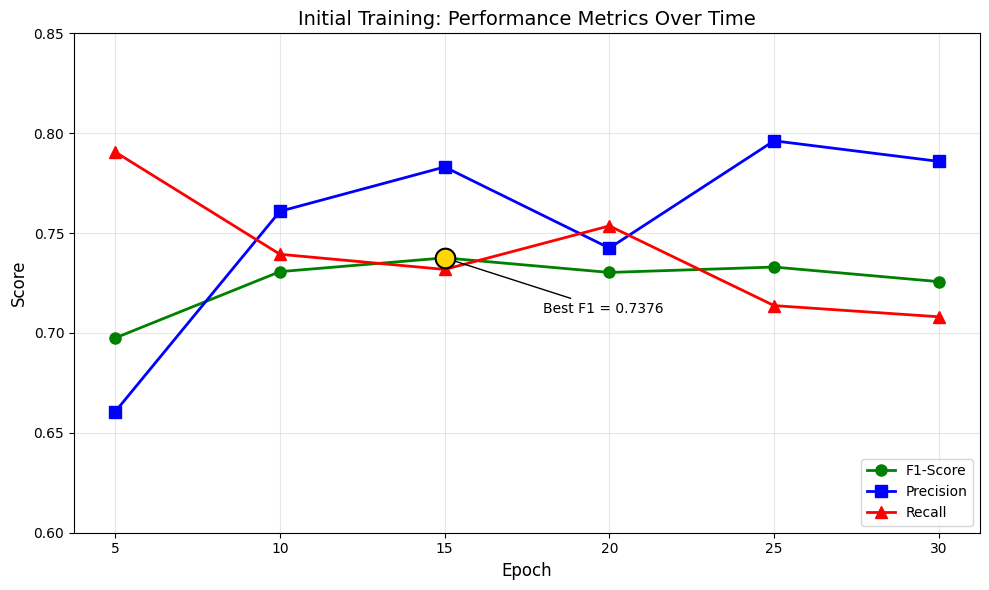

In [ ]:
# Data for initial training
epochs_initial = [5, 10, 15, 20, 25, 30]
f1_scores = [0.6975, 0.7307, 0.7376, 0.7303, 0.7330, 0.7257]
precision = [0.6606, 0.7609, 0.7831, 0.7425, 0.7962, 0.7859]
recall = [0.7906, 0.7394, 0.7318, 0.7536, 0.7137, 0.7081]

plt.figure(figsize=(10, 6))
plt.plot(epochs_initial, f1_scores, 'g-', linewidth=2, label='F1-Score', marker='o', markersize=8)
plt.plot(epochs_initial, precision, 'b-', linewidth=2, label='Precision', marker='s', markersize=8)
plt.plot(epochs_initial, recall, 'r-', linewidth=2, label='Recall', marker='^', markersize=8)

# Highlight best F1
plt.scatter([15], [0.7376], color='gold', s=200, zorder=5, edgecolors='black', linewidth=1.5)
plt.annotate('Best F1 = 0.7376', xy=(15, 0.7376), xytext=(18, 0.71),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Initial Training: Performance Metrics Over Time', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0.6, 0.85)
plt.tight_layout()
plt.savefig('figure2_initial_performance.png', dpi=300)
plt.show()

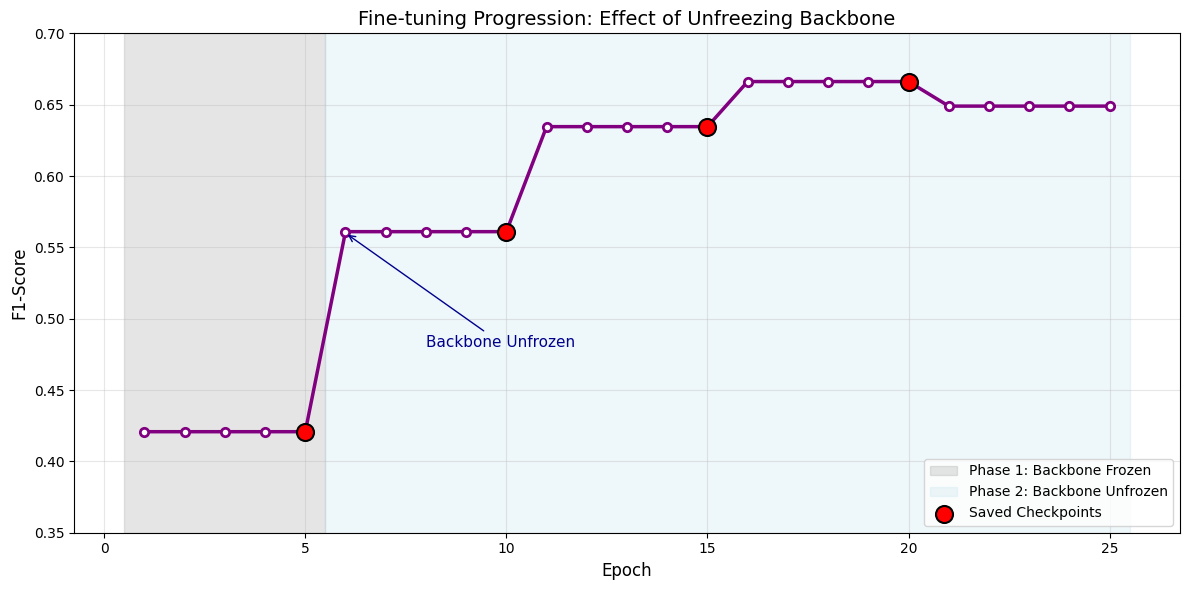

In [ ]:
# Fine-tuning data (Run 1)
ft_epochs_full = list(range(1, 26))
ft_f1 = [0.4208, None, None, None, 0.4208, 0.5610, None, None, None, 0.5610,
         0.6346, None, None, None, 0.6346, 0.6662, None, None, None, 0.6662,
         0.6490, None, None, None, 0.6490]

# Clean up for plotting (forward fill)
ft_f1_clean = []
last_val = 0.4208
for val in ft_f1:
    if val is not None:
        last_val = val
    ft_f1_clean.append(last_val)

plt.figure(figsize=(12, 6))

# Create phase background
plt.axvspan(0.5, 5.5, alpha=0.2, color='gray', label='Phase 1: Backbone Frozen')
plt.axvspan(5.5, 25.5, alpha=0.2, color='lightblue', label='Phase 2: Backbone Unfrozen')

plt.plot(ft_epochs_full, ft_f1_clean, 'purple', linewidth=2.5, marker='o', markersize=6,
         markerfacecolor='white', markeredgewidth=2)

# Mark saved checkpoints
saved_epochs = [5, 10, 15, 20]
saved_f1 = [0.4208, 0.5610, 0.6346, 0.6662]
plt.scatter(saved_epochs, saved_f1, color='red', s=150, zorder=5, edgecolors='black',
            linewidth=1.5, label='Saved Checkpoints')

# Add phase transition annotation
plt.annotate('Backbone Unfrozen', xy=(6, 0.56), xytext=(8, 0.48),
             arrowprops=dict(arrowstyle='->', color='darkblue'), fontsize=11, color='darkblue')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('Fine-tuning Progression: Effect of Unfreezing Backbone', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0.35, 0.70)
plt.tight_layout()
plt.savefig('figure3_finetuning_progress.png', dpi=300)
plt.show()

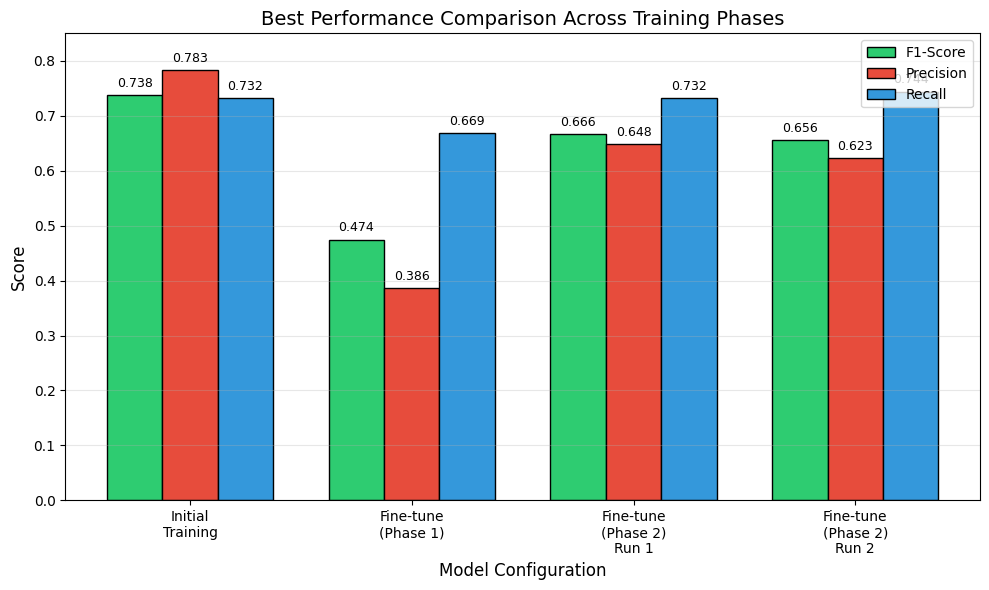

In [ ]:
models = ['Initial\nTraining', 'Fine-tune\n(Phase 1)', 'Fine-tune\n(Phase 2)\nRun 1', 'Fine-tune\n(Phase 2)\nRun 2']
best_f1 = [0.7376, 0.4745, 0.6662, 0.6557]
best_precision = [0.7831, 0.3863, 0.6480, 0.6225]
best_recall = [0.7318, 0.6686, 0.7319, 0.7438]
colors = ['#2ecc71', '#e74c3c', '#3498db', '#3498db']

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, best_f1, width, label='F1-Score', color=colors[0], edgecolor='black')
bars2 = ax.bar(x, best_precision, width, label='Precision', color=colors[1], edgecolor='black')
bars3 = ax.bar(x + width, best_recall, width, label='Recall', color=colors[2], edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model Configuration', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Best Performance Comparison Across Training Phases', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 0.85)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figure4_performance_comparison.png', dpi=300)
plt.show()

/tmp/ipykernel_1446/265289605.py:22: RuntimeWarning: divide by zero encountered in divide
  precision_line = (f1_val * recall_line) / (2 * recall_line - f1_val)


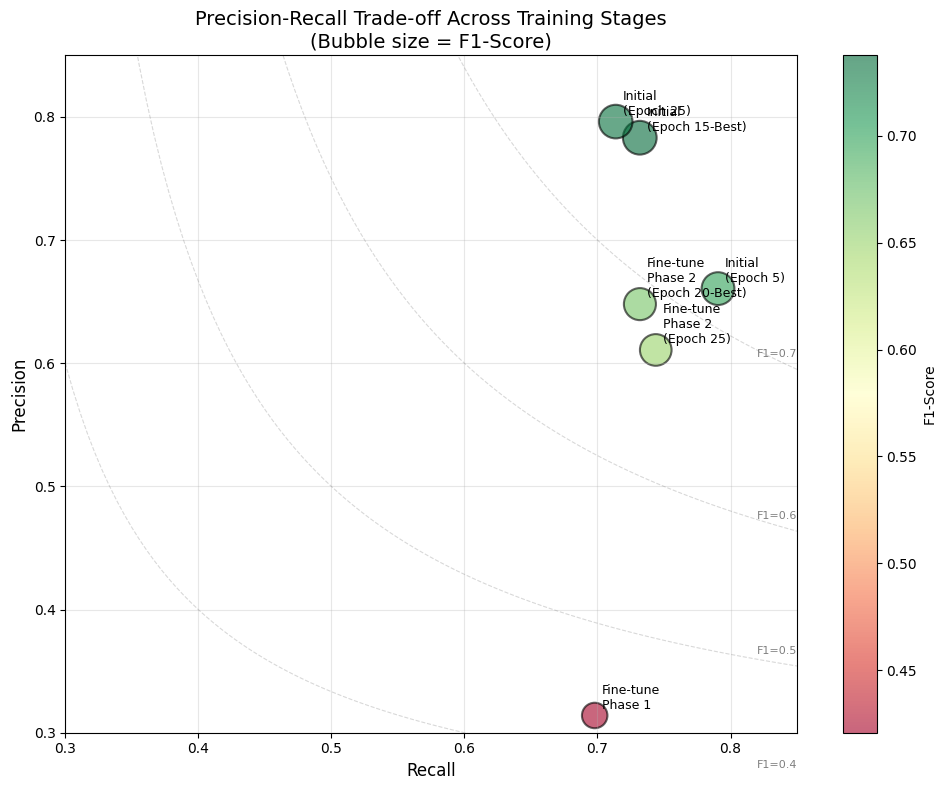

In [ ]:
# Data points for different training stages
stages = ['Initial\n(Epoch 5)', 'Initial\n(Epoch 15-Best)', 'Initial\n(Epoch 25)',
          'Fine-tune\nPhase 1', 'Fine-tune\nPhase 2\n(Epoch 20-Best)', 'Fine-tune\nPhase 2\n(Epoch 25)']
precision_points = [0.6606, 0.7831, 0.7962, 0.3140, 0.6480, 0.6108]
recall_points = [0.7906, 0.7318, 0.7137, 0.6979, 0.7319, 0.7438]
f1_points = [0.6975, 0.7376, 0.7330, 0.4208, 0.6662, 0.6490]

plt.figure(figsize=(10, 8))

# Create bubble plot (size = F1-score)
scatter = plt.scatter(recall_points, precision_points, s=[f*800 for f in f1_points],
                      c=f1_points, cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidth=1.5)

# Add labels for each point
for i, stage in enumerate(stages):
    plt.annotate(stage, (recall_points[i], precision_points[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9, ha='left')

# Add diagonal lines for constant F1
recall_line = np.linspace(0.3, 0.85, 100)
for f1_val in [0.4, 0.5, 0.6, 0.7]:
    precision_line = (f1_val * recall_line) / (2 * recall_line - f1_val)
    plt.plot(recall_line, precision_line, 'gray', linestyle='--', alpha=0.3, linewidth=0.8)
    plt.text(0.82, precision_line[-1] + 0.01, f'F1={f1_val}', fontsize=8, alpha=0.5)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Trade-off Across Training Stages\n(Bubble size = F1-Score)', fontsize=14)
plt.xlim(0.3, 0.85)
plt.ylim(0.3, 0.85)
plt.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('F1-Score', fontsize=10)

plt.tight_layout()
plt.savefig('figure5_precision_recall_tradeoff.png', dpi=300)
plt.show()